
# **Taller de Clase: Regresión con Machine Learning: Predicción del precio de vivienda por unidad de área: Real Estate Valuation Dataset**

# **Preparación e investigación teórica**

Predicción del precio de vivienda por unidad de área
Real Estate Valuation Data Set — UCI ML Repository
UCSG — Big Data / Machine Learning — Grupo B

## Integrantes del Proyecto

- <span style="color:#0072BD"><b>Mario Steve Ocaña Avilés</b></span>  

- <span style="color:#0072BD"><b>Jerylene Isabel Martínez Rodríguez</b></span>  

- <span style="color:#0072BD"><b>Gabriel Alejandro Baque Perez</b></span>  

- <span style="color:#0072BD"><b>Evelyn Noemi Guamán Tarco</b></span>

- <span style="color:#0072BD"><b>Lindsey Nahomy Pallazhco Ramirez</b></span>  


# Fase 0: Investigación Teórica de Métricas de Regresión

## 1. Diferencia entre Regresión y Clasificación

En **clasificación** la variable objetivo es **categórica** (discreta), por lo que se evalúa si la clase predicha coincide con la real (accuracy, precision, recall, F1).

En **regresión** la variable objetivo es **continua** (un número real), por lo que no tiene sentido hablar de "aciertos"; en su lugar medimos **la magnitud del error** entre el valor predicho y el real.

---

## 2. Tabla Resumen de Métricas

| Métrica | Fórmula | Unidades | Qué mide | Cuándo usarla |
|---------|---------|----------|----------|---------------|
| **MAE** | (1/n) × Σ\|y - ŷᵢ\| | Mismas que Y | Error absoluto promedio | Interpretación simple, robusta a outliers |
| **MSE** | (1/n) × Σ(yᵢ - ŷᵢ)² | Unidades de Y² | Error cuadrático promedio | Penaliza errores grandes |
| **RMSE** | √MSE | Mismas que Y | Desviación típica de los residuos | Comparar modelos cuando importan los outliers |
| **MAPE** | (100/n) × Σ\|(y - ŷᵢ)/yᵢ\| | Porcentaje (%) | Error relativo medio | Comparar error en términos relativos; evitar si y=0 |
| **R²** | 1 - (SS_res/SS_tot) | Adimensional (0-1) | Proporción de varianza explicada | Comparación rápida; puede engañar con muchas variables |
| **R² Ajustado** | 1 - (1-R²)×(n-1)/(n-p-1) | Adimensional | R² penalizado por n° de predictores | Comparar modelos con distinto n° de variables |

---

## 3. Preguntas Clave

### ¿Por qué el R² por sí solo puede engañar?

Por construcción matemática, el R² **nunca disminuye** al añadir variables nuevas, aunque estas no aporten información real. Esto favorece modelos sobreajustados. El **R² ajustado** corrige este efecto penalizando el uso de predictores innecesarios.

**Ejemplo:** Si añades una variable aleatoria que no tiene relación con Y, el R² subirá ligeramente, pero el R² ajustado bajará porque penaliza el número de predictores.

---

### RMSE vs MAE con outliers

**RMSE** eleva los errores al cuadrado → **penaliza fuertemente los outliers**.
- ✅ Útil cuando un error grande es inaceptable (ej. precios muy lejanos)
- ❌ Puede ser dominado por pocos valores atípicos

**MAE** trata todos los errores linealmente → **es más robusto a outliers**.
- ✅ Preferible cuando los valores atípicos son ruido y no deberían dominar la métrica
- ❌ No distingue entre errores pequeños y grandes de forma proporcional

---

## 4. Fuentes Consultadas

- Documentación oficial de `scikit-learn`: [sklearn.metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics)
- "An Introduction to Statistical Learning" (James et al., Capítulo 2)
- Apuntes de clase de Machine Learning/Big Data

---

> 📝 **Nota:** Todas las fórmulas están expresadas en notación matemática estándar. En la implementación usamos las funciones de `sklearn.metrics` que calculan estas métricas de forma optimizada.

In [72]:
# FASE 0: Configuración del Entorno, Estilo y Carga de Datos

# 1. Instalación de librerías necesarias
!pip install plotly xgboost openpyxl shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
import warnings
warnings.filterwarnings('ignore')

# ==========================================================
# CONFIGURACIÓN GLOBAL DE ESTILO (PALETA MATLAB)
# ==========================================================
# Colores clásicos de MATLAB para gráficos categóricos (barras, líneas)
matlab_colors = ['#0072BD', '#D95319', '#EDB120', '#7E2F8E', '#77AC30', '#4DBEEE', '#A2142F']

# Configurar Matplotlib y Seaborn
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=matlab_colors)
sns.set_palette(matlab_colors)
sns.set_theme(style="whitegrid", font_scale=1.1)

# Configurar Plotly con tema "matlab"
matlab_template = go.layout.Template(
    layout=go.Layout(
        colorway=matlab_colors,
        plot_bgcolor="white",
        paper_bgcolor="white",
        font=dict(family="Arial, sans-serif", size=12, color="black"),
        xaxis=dict(showgrid=True, gridcolor="lightgray", zeroline=False, showline=True, linecolor="black"),
        yaxis=dict(showgrid=True, gridcolor="lightgray", zeroline=False, showline=True, linecolor="black")
    )
)
pio.templates["matlab"] = matlab_template
pio.templates.default = "matlab"

# Paleta "Parula" (colores de mapas de calor de MATLAB) para usar en heatmaps de Plotly
parula_colors = [
    "#3B0F70", "#461E85", "#4A2C97", "#483D9D", "#403CAA",
    "#355CB3", "#2B7AB8", "#2191BC", "#1AA6B8", "#25BBB0",
    "#42C99C", "#6CD382", "#9DD963", "#D1E753", "#FDE725"
]

# ==========================================================
# CARGA DE DATOS DESDE GITHUB (URL RAW)
# ==========================================================
# El enlace github es de la interfaz web. Para que pandas lo lea,
# debemos usar el enlace en formato RAW (texto plano).
url_raw = "https://raw.githubusercontent.com/jermrodr/BIG-DATA/33691c6877a671a47100e75be22b4441b7e55848/Real%20estate%20valuation%20data%20set.xlsx"

try:
    df = pd.read_excel(url_raw)
    print("✅ Dataset cargado correctamente desde GitHub.")
    print(f"📊 Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
    display(df.head())
except Exception as e:
    print(f"❌ Error al cargar el dataset: {e}")

✅ Dataset cargado correctamente desde GitHub.
📊 Dimensiones: 414 filas y 8 columnas.


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [79]:
# ==========================================================
# FASE 2: ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ==========================================================

print("="*50)
print("1. REVISIÓN INICIAL DE DATOS")
print("="*50)
display(df.info())

print("\n--- Valores Nulos y Duplicados ---")
print(f"Valores nulos por columna:\n{df.isnull().sum()}")
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

print("\n" + "="*50)
print("2. ESTADÍSTICA DESCRIPTIVA")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("3. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Y)")
print("="*50)

# Configuración responsive para evitar espacios vacíos
plotly_config = {
    'responsive': True,
    'displaylogo': False
}

# ==========================================================
# HISTOGRAMA DE LA VARIABLE OBJETIVO
# ==========================================================

y_col = 'Y house price of unit area'

fig_hist_y = px.histogram(
    df,
    x=y_col,
    title='Precio de vivienda por unidad de área (Y)',
    color_discrete_sequence=['#0072BD']  # Azul MATLAB
)

fig_hist_y.update_traces(
    xbins=dict(
        start=df[y_col].min(),
        end=120,
        size=8
    ),
    opacity=0.90,
    marker_line_width=0
)

fig_hist_y.update_layout(
    template='matlab',
    autosize=True,
    height=620,
    bargap=0.00,
    showlegend=False,
    title_x=0.5,
    xaxis_title='Precio de Vivienda por Unidad de Área (10,000 NT$/Ping)',
    yaxis_title='Frecuencia',
    margin=dict(t=70, b=70, l=80, r=40)
)

fig_hist_y.update_xaxes(
    range=[0, 122],
    tickmode='array',
    tickvals=[20, 40, 60, 80, 100, 120]
)

fig_hist_y.update_yaxes(
    range=[0, 110],
    tickmode='array',
    tickvals=[0, 20, 40, 60, 80, 100]
)

fig_hist_y.show(config=plotly_config)


# ==========================================================
# BOXPLOT HORIZONTAL DE LA VARIABLE OBJETIVO
# ==========================================================

fig_box_y = px.box(
    df,
    x='Y house price of unit area',
    orientation='h',
    title='Boxplot Horizontal del Precio de Vivienda por Unidad de Área (Y)',
    labels={'Y house price of unit area': 'Precio'}
)

fig_box_y.update_traces(
    marker_color='#7E2F8E',
    line_color='#7E2F8E',
    boxmean=True
)

fig_box_y.update_layout(
    template='matlab',
    autosize=True,
    height=450,
    xaxis_title='Precio (10,000 NT$/Ping)',
    yaxis_title='',
    showlegend=False,
    title_x=0.5,
    margin=dict(t=80, b=70, l=80, r=40)
)

fig_box_y.update_xaxes(
    range=[0, 125],
    tickmode='array',
    tickvals=[20, 40, 60, 80, 100, 120]
)

fig_box_y.show(config=plotly_config)


# ==========================================================
# MATRIZ DE CORRELACIÓN Y HEATMAP
# ==========================================================

print("\n" + "="*50)
print("4. MATRIZ DE CORRELACIÓN Y HEATMAP")
print("="*50)

# Calcular matriz de correlación
corr_matrix = df.drop(columns=['No']).corr()

# Crear la escala de colores Parula para Plotly
parula_scale = [[i/(len(parula_colors)-1), color] for i, color in enumerate(parula_colors)]

fig_heatmap = px.imshow(
    corr_matrix,
    aspect="auto",
    color_continuous_scale=parula_scale,
    title='Matriz de Correlación entre Variables',
    labels={'color': 'Correlación'}
)

fig_heatmap.update_traces(
    texttemplate="%{z:.2f}",
    textfont_size=10
)

fig_heatmap.update_layout(
    template='matlab',
    autosize=True,
    height=850,
    title_x=0.5,
    margin=dict(
        l=230,   # espacio suficiente para nombres largos del eje Y
        r=120,   # espacio para barra de color
        t=90,
        b=210    # espacio para etiquetas inclinadas del eje X
    ),
    coloraxis_colorbar=dict(
        title='Correlación',
        thickness=18,
        len=0.80,
        x=1.02
    )
)

fig_heatmap.update_xaxes(
    tickangle=-45,
    automargin=True,
    constrain='domain'
)

fig_heatmap.update_yaxes(
    automargin=True,
    constrain='domain'
)

fig_heatmap.show(config=plotly_config)


# ==========================================================
# DETECCIÓN DE OUTLIERS EN VARIABLES PREDICTORAS
# ==========================================================

print("\n" + "="*50)
print("5. DETECCIÓN DE OUTLIERS EN VARIABLES PREDICTORAS")
print("="*50)

features_to_check = [
    'X2 house age',
    'X3 distance to the nearest MRT station',
    'X4 number of convenience stores'
]

fig_outliers = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=features_to_check,
    horizontal_spacing=0.08
)

for i, feature in enumerate(features_to_check):
    fig_outliers.add_trace(
        go.Box(
            y=df[feature],
            name=feature,
            marker_color=matlab_colors[i]
        ),
        row=1,
        col=i+1
    )

fig_outliers.update_layout(
    title_text="Detección de Outliers en Variables Predictoras",
    title_x=0.5,
    showlegend=False,
    template='matlab',
    autosize=True,
    height=520,
    margin=dict(t=90, b=80, l=70, r=40)
)

fig_outliers.update_yaxes(automargin=True)
fig_outliers.update_xaxes(automargin=True)

fig_outliers.show(config=plotly_config)


# ==========================================================
# RELACIÓN ENTRE FEATURES Y TARGET
# ==========================================================

print("\n" + "="*50)
print("6. RELACIÓN ENTRE FEATURES Y TARGET (SCATTER PLOTS)")
print("="*50)

fig_scatter = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=features_to_check,
    horizontal_spacing=0.08
)

for i, feature in enumerate(features_to_check):
    fig_scatter.add_trace(
        go.Scatter(
            x=df[feature],
            y=df['Y house price of unit area'],
            mode='markers',
            marker_color=matlab_colors[i],
            name=feature,
            marker_size=6,
            opacity=0.7
        ),
        row=1,
        col=i+1
    )

fig_scatter.update_layout(
    title_text="Relación entre Variables Predictoras y Precio (Y)",
    title_x=0.5,
    showlegend=False,
    template='matlab',
    autosize=True,
    height=520,
    margin=dict(t=90, b=80, l=80, r=40)
)


# Eje Y (Precio) - solo en la primera columna para que no se repita
fig_scatter.update_yaxes(
    title_text='Precio de Vivienda por Unidad de Área (10,000 NT$/Ping)',
    row=1,
    col=1,
    automargin=True
)

# Eje X (cada feature con su nombre específico)
fig_scatter.update_xaxes(
    title_text='Edad de la Vivienda (años)',  # X2
    row=1,
    col=1,
    automargin=True
)

fig_scatter.update_xaxes(
    title_text='Distancia al MRT (m)',  # X3
    row=1,
    col=2,
    automargin=True
)

fig_scatter.update_xaxes(
    title_text='N° Tiendas de Conveniencia',  # X4
    row=1,
    col=3,
    automargin=True
)

fig_scatter.show(config=plotly_config)

1. REVISIÓN INICIAL DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB


None


--- Valores Nulos y Duplicados ---
Valores nulos por columna:
No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

Filas duplicadas: 0

2. ESTADÍSTICA DESCRIPTIVA


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,207.500000,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,119.655756,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,1.000000,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,104.250000,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,207.500000,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,310.750000,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,414.000000,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000



3. DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Y)



4. MATRIZ DE CORRELACIÓN Y HEATMAP



5. DETECCIÓN DE OUTLIERS EN VARIABLES PREDICTORAS



6. RELACIÓN ENTRE FEATURES Y TARGET (SCATTER PLOTS)


In [74]:
# ==========================================================
# 3.1 VISUALIZACIONES ADICIONALES DEL EDA (PLOTLY)
# ==========================================================

import plotly.graph_objects as go
from plotly.subplots import make_subplots

print("\n" + "="*50)
print("3.1 VISUALIZACIONES ADICIONALES DE DISTRIBUCIÓN")
print("="*50)

plotly_config = {
    'responsive': True,
    'displaylogo': False
}

# Función para crear bins semejantes a hist(bins=15) de Matplotlib
def get_xbins(series, bins=15):
    min_val = series.min()
    max_val = series.max()
    bin_size = (max_val - min_val) / bins
    return dict(start=min_val, end=max_val, size=bin_size)


# ----------------------------------------------------------
# Visualizar distribución de variables continuas: X2 y X3
# ----------------------------------------------------------
fig_hist_x2_x3 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'X2 house age',
        'X3 distance to the nearest MRT station'
    ),
    horizontal_spacing=0.12
)

fig_hist_x2_x3.add_trace(
    go.Histogram(
        x=df['X2 house age'],
        xbins=get_xbins(df['X2 house age'], bins=15),
        marker_color=matlab_colors[0],
        opacity=0.90,
        name='X2 house age'
    ),
    row=1,
    col=1
)

fig_hist_x2_x3.add_trace(
    go.Histogram(
        x=df['X3 distance to the nearest MRT station'],
        xbins=dict(
            start=0,
            end=6600,
            size=440
        ),
        marker_color=matlab_colors[1],
        opacity=0.90,
        name='X3 distance to the nearest MRT station'
    ),
    row=1,
    col=2
)

fig_hist_x2_x3.update_layout(
    template='matlab',
    height=560,
    width=1350,
    showlegend=False,
    bargap=0.00,
    title_text='Distribución de variables continuas',
    title_x=0.5,
    margin=dict(t=90, b=80, l=80, r=60)
)

fig_hist_x2_x3.update_xaxes(
    title_text='',
    range=[0, 45],
    row=1,
    col=1
)

fig_hist_x2_x3.update_xaxes(
    title_text='',
    range=[0, 6600],
    tickmode='array',
    tickvals=[0, 1000, 2000, 3000, 4000, 5000, 6000],
    ticktext=['0', '1000', '2000', '3000', '4000', '5000', '6000'],
    row=1,
    col=2,
    automargin=True
)

fig_hist_x2_x3.update_yaxes(
    title_text='Frecuencia',
    rangemode='tozero',
    row=1,
    col=1
)

fig_hist_x2_x3.update_yaxes(
    title_text='Frecuencia',
    range=[0, 200],
    tickmode='array',
    tickvals=[0, 25, 50, 75, 100, 125, 150, 175],
    row=1,
    col=2
)

fig_hist_x2_x3.show(config=plotly_config)


# ----------------------------------------------------------
# Visualizar X1 transaction date y X4 number of convenience stores
# ----------------------------------------------------------
x1_counts = df['X1 transaction date'].value_counts().sort_index()

# X4 con todos los valores del eje X: 0, 1, 2, ..., 10
x4_counts = df['X4 number of convenience stores'].value_counts().reindex(range(0, 11), fill_value=0)

fig_x1_x4 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'X1 transaction date',
        'X4 number of convenience stores'
    ),
    horizontal_spacing=0.12
)

fig_x1_x4.add_trace(
    go.Bar(
        x=[str(round(x, 6)) for x in x1_counts.index],
        y=x1_counts.values,
        marker_color=matlab_colors[3],
        marker_line_color='white',
        marker_line_width=0.8,
        name='X1 transaction date'
    ),
    row=1,
    col=1
)

fig_x1_x4.add_trace(
    go.Bar(
        x=[str(x) for x in x4_counts.index],
        y=x4_counts.values,
        marker_color=matlab_colors[4],
        marker_line_color='white',
        marker_line_width=0.8,
        name='X4 number of convenience stores'
    ),
    row=1,
    col=2
)

fig_x1_x4.update_layout(
    template='matlab',
    height=580,
    width=1350,
    showlegend=False,
    bargap=0.12,
    title_text='Distribución de variables discretas',
    title_x=0.5,
    margin=dict(t=90, b=140, l=80, r=60)
)

fig_x1_x4.update_xaxes(
    title_text='',
    tickangle=-45,
    row=1,
    col=1
)

fig_x1_x4.update_xaxes(
    title_text='',
    tickmode='array',
    tickvals=[str(i) for i in range(0, 11)],
    ticktext=[str(i) for i in range(0, 11)],
    categoryorder='array',
    categoryarray=[str(i) for i in range(0, 11)],
    row=1,
    col=2
)

fig_x1_x4.update_yaxes(
    title_text='Frecuencia',
    rangemode='tozero',
    row=1,
    col=1
)

fig_x1_x4.update_yaxes(
    title_text='Frecuencia',
    rangemode='tozero',
    row=1,
    col=2
)

fig_x1_x4.show(config=plotly_config)


# ----------------------------------------------------------
# Visualizar distribución de latitud y longitud
# ----------------------------------------------------------
fig_hist_x5_x6 = make_subplots(
    rows=1, cols=2,
    subplot_titles=(
        'X5 latitude',
        'X6 longitude'
    ),
    horizontal_spacing=0.12
)

fig_hist_x5_x6.add_trace(
    go.Histogram(
        x=df['X5 latitude'],
        xbins=get_xbins(df['X5 latitude'], bins=15),
        marker_color=matlab_colors[0],
        opacity=0.90,
        name='X5 latitude'
    ),
    row=1,
    col=1
)

fig_hist_x5_x6.add_trace(
    go.Histogram(
        x=df['X6 longitude'],
        xbins=get_xbins(df['X6 longitude'], bins=15),
        marker_color=matlab_colors[0],
        opacity=0.90,
        name='X6 longitude'
    ),
    row=1,
    col=2
)

fig_hist_x5_x6.update_layout(
    template='matlab',
    height=560,
    width=1350,
    showlegend=False,
    bargap=0.03,
    title_text='Distribución de latitud y longitud',
    title_x=0.5,
    margin=dict(t=90, b=80, l=80, r=60)
)

fig_hist_x5_x6.update_xaxes(
    range=[24.93, 25.02],
    row=1,
    col=1
)

fig_hist_x5_x6.update_xaxes(
    range=[121.47, 121.57],
    row=1,
    col=2
)

fig_hist_x5_x6.update_yaxes(
    title_text='Frecuencia',
    rangemode='tozero',
    row=1,
    col=1
)

fig_hist_x5_x6.update_yaxes(
    title_text='Frecuencia',
    rangemode='tozero',
    row=1,
    col=2
)

fig_hist_x5_x6.show(config=plotly_config)


# ----------------------------------------------------------
# Visualizar distribución geográfica del precio
# ESTA DEBE IR SÍ O SÍ
# ----------------------------------------------------------
fig_geo_scatter = go.Figure()

fig_geo_scatter.add_trace(
    go.Scatter(
        x=df['X6 longitude'],
        y=df['X5 latitude'],
        mode='markers',
        marker=dict(
            size=df['Y house price of unit area'],
            sizemode='area',
            sizeref=2.0 * df['Y house price of unit area'].max() / (35 ** 2),
            sizemin=3,
            color=df['Y house price of unit area'],
            colorscale='Jet',
            cmin=df['Y house price of unit area'].min(),
            cmax=df['Y house price of unit area'].max(),
            colorbar=dict(
                title='Y house price<br>of unit area',
                thickness=18,
                len=0.85,
                x=1.02
            ),
            opacity=0.4,
            line=dict(width=0)
        ),
        name='house price of unit area',
        hovertemplate=
            '<b>Longitud:</b> %{x:.5f}<br>' +
            '<b>Latitud:</b> %{y:.5f}<br>' +
            '<b>Precio:</b> %{marker.color:.2f}<extra></extra>'
    )
)

fig_geo_scatter.update_layout(
    title_text='Geographical distribution of house prices of unit area',
    title_x=0.5,
    xaxis_title='X6 longitude',
    yaxis_title='X5 latitude',
    template='matlab',
    height=620,
    width=1350,
    showlegend=True,
    margin=dict(t=80, b=80, l=90, r=100),
    legend=dict(
        x=0.02,
        y=0.98,
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='lightgray',
        borderwidth=1
    )
)

fig_geo_scatter.update_xaxes(
    range=[121.47, 121.57],
    domain=[0.00, 0.92]
)

fig_geo_scatter.update_yaxes(
    range=[24.93, 25.02]
)

fig_geo_scatter.show(config=plotly_config)


3.1 VISUALIZACIONES ADICIONALES DE DISTRIBUCIÓN


# FASE 3: PREPROCESAMIENTO Y PREPARACIÓN DE DATOS

### 📌 Decisión sobre Outliers en la Variable Objetivo (Y)
En el boxplot de la Fase 2, se observó un valor extremo en **117.5** (el límite superior del bigote es ~60).
**Justificación Técnica:** En el contexto inmobiliario de Taiwán (donde el precio promedio es ~38), un valor de 117.5 representa una transacción anómala (posible error de digitación o una propiedad de lujo extremo no representativa). Dado que la Regresión Lineal es matemáticamente muy sensible a los outliers y el MSE/RMSE penalizarían desproporcionadamente este error, **se decidirá eliminar esta fila** para evitar que el modelo sesgue sus predicciones hacia un caso atípico.

> *Nota sobre Data Leakage:* Las transformaciones aplicadas a continuación (`log1p` y conversión de fechas) son operaciones fila por fila que no dependen de estadísticas globales (como la media o desviación), por lo que no generan fuga de datos (*data leakage*). Sin embargo, el escalado (`StandardScaler`) se aplicará estrictamente después de la división Train/Test.

In [75]:
# ==========================================================
# FASE 3: PREPROCESAMIENTO DE DATOS
# ==========================================================

print("="*60)
print("FASE 3: PREPROCESAMIENTO Y PREPARACIÓN DE DATOS")
print("="*60)

# ----------------------------------------------------------
# 3.1. ELIMINACIÓN DE COLUMNA IDENTIFICADORA (No)
# ----------------------------------------------------------
print("\n🔹 3.1. Eliminando columna 'No' (identificador secuencial)...")
df_clean = df.drop(columns=['No']).copy()
print(f"✅ Columnas restantes: {df_clean.columns.tolist()}")

# ----------------------------------------------------------
# 3.2. LIMPIEZA DEL OUTLIER EXTREMO EN LA VARIABLE OBJETIVO (Y)
# ----------------------------------------------------------
print("\n🔹 3.2. Limpiando outlier extremo en 'Y' (precio = 117.5)...")
print(f"   Filas antes de limpiar: {len(df_clean)}")

# Identificamos y eliminamos la fila con precio > 100 (outlier evidente)
outlier_mask = df_clean['Y house price of unit area'] > 100
print(f"   Outliers detectados en Y (>100): {outlier_mask.sum()}")

df_clean = df_clean[~outlier_mask].reset_index(drop=True)
print(f"✅ Filas después de limpiar: {len(df_clean)}")

# ----------------------------------------------------------
# 3.3. INGENIERÍA DE CARACTERÍSTICAS: TRANSFORMACIÓN DE FECHA
# ----------------------------------------------------------
print("\n🔹 3.3. Transformando fecha decimal a 'meses transcurridos'...")
year = df_clean['X1 transaction date'].astype(int)
month_decimal = df_clean['X1 transaction date'] - year
month = (month_decimal * 12).round().astype(int)

df_clean['X1_months_since_start'] = (year - 2012) * 12 + month
df_clean = df_clean.drop(columns=['X1 transaction date'])
print(f"✅ Nueva columna 'X1_months_since_start' creada. Rango: {df_clean['X1_months_since_start'].min()} a {df_clean['X1_months_since_start'].max()} meses")

# ----------------------------------------------------------
# 3.4. TRANSFORMACIÓN DE LA DISTANCIA AL MRT (X3)
# ----------------------------------------------------------
print("\n🔹 3.4. Aplicando transformación logarítmica a la distancia al MRT...")
df_clean['X3_distance_original'] = df_clean['X3 distance to the nearest MRT station']
df_clean['X3 distance to the nearest MRT station'] = np.log1p(df_clean['X3 distance to the nearest MRT station'])
print(f"✅ Distancia transformada. Rango original: 23 - 6488 m | Rango log: {df_clean['X3 distance to the nearest MRT station'].min():.2f} - {df_clean['X3 distance to the nearest MRT station'].max():.2f}")

# ----------------------------------------------------------
# 3.5. SEPARACIÓN DE FEATURES (X) Y TARGET (y)
# ----------------------------------------------------------
print("\n🔹 3.5. Separando variables predictoras (X) y variable objetivo (y)...")
X = df_clean.drop(columns=['Y house price of unit area', 'X3_distance_original'])
y = df_clean['Y house price of unit area']

print(f"✅ Shape de X (features): {X.shape}")
print(f"✅ Shape de y (target): {y.shape}")
print(f"   Features finales: {X.columns.tolist()}")

# ----------------------------------------------------------
# 3.6. DIVISIÓN TRAIN / TEST (80% / 20%)
# ----------------------------------------------------------
print("\n🔹 3.6. Dividiendo datos en Train (80%) y Test (20%)...")
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"✅ Train: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras")

# ----------------------------------------------------------
# 3.7. ESCALADO DE VARIABLES (StandardScaler)
# ----------------------------------------------------------
print("\n🔹 3.7. Aplicando escalado estándar (StandardScaler)...")
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajustamos el escalador SOLO con los datos de train (evita data leakage)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("✅ Escalado completado.")
print("\n📊 Comparativa de medias y desviaciones ANTES vs DESPUÉS del escalado:")
print("\n--- ANTES (X_train original) ---")
print(X_train.describe().loc[['mean', 'std']].round(3))
print("\n--- DESPUÉS (X_train_scaled) ---")
print(X_train_scaled.describe().loc[['mean', 'std']].round(3))

print("\n" + "="*60)
print("✅ FASE 3 COMPLETADA - RESUMEN")
print("="*60)
print(f"📌 Dataset final: {len(df_clean)} registros limpios")
print(f"📌 Features utilizadas: {X.shape[1]}")
print(f"📌 Transformaciones aplicadas:")
print("   • Eliminada columna 'No' (ID)")
print("   • Eliminado 1 outlier extremo en Y (precio = 117.5)")
print("   • Fecha convertida a 'meses transcurridos'")
print("   • Distancia al MRT transformada con log1p")
print(f"📌 División: Train={len(X_train)} | Test={len(X_test)}")
print("📌 Escalado: StandardScaler aplicado")
print("\n🎯 Los datos están listos para la FASE 4: MODELADO")


# ----------------------------------------------------------
# 3.5. VISUALIZACIÓN COMPARATIVA: ANTES vs DESPUÉS (NIVEL KAGGLE)
# ----------------------------------------------------------
print("\n🔹 3.5. Generando comparativas visuales de las transformaciones...")

# ==============================
# GRÁFICA 1: Limpieza del Outlier en Y
# ==============================
fig_outlier_y = make_subplots(rows=1, cols=2,
                              subplot_titles=['ANTES: Y con outlier (n=414)',
                                              'DESPUÉS: Y sin outlier (n=413)'])

# Antes (con el outlier de 117.5)
fig_outlier_y.add_trace(
    go.Box(y=df['Y house price of unit area'], name='Y original',
           marker_color='#A2142F', boxmean=True),
    row=1, col=1
)

# Después (sin outlier)
fig_outlier_y.add_trace(
    go.Box(y=df_clean['Y house price of unit area'], name='Y limpio',
           marker_color='#0072BD', boxmean=True),
    row=1, col=2
)

fig_outlier_y.update_layout(
    title_text="📊 Impacto de la Eliminación del Outlier (Y = 117.5)",
    title_x=0.5, template='matlab', height=450, showlegend=False
)
fig_outlier_y.show()

# ==============================
# GRÁFICA 2: Transformación Logarítmica en X3 (Distancia MRT)
# ==============================
fig_log_x3 = make_subplots(rows=1, cols=2,
                           subplot_titles=['ANTES: Distancia MRT (metros, sesgada)',
                                           'DESPUÉS: log1p(Distancia MRT)'])

# Antes
fig_log_x3.add_trace(
    go.Histogram(x=df['X3 distance to the nearest MRT station'], nbinsx=30,
                 marker_color='#A2142F', name='Original', opacity=0.85),
    row=1, col=1
)

# Después
fig_log_x3.add_trace(
    go.Histogram(x=df_clean['X3 distance to the nearest MRT station'], nbinsx=30,
                 marker_color='#0072BD', name='Transformada', opacity=0.85),
    row=1, col=2
)

fig_log_x3.update_layout(
    title_text="📊 Reducción de Sesgo con Transformación log1p",
    title_x=0.5, template='matlab', height=450, showlegend=False
)
fig_log_x3.update_xaxes(title_text="Metros", row=1, col=1)
fig_log_x3.update_xaxes(title_text="log(1 + metros)", row=1, col=2)
fig_log_x3.update_yaxes(title_text="Frecuencia", row=1, col=1)
fig_log_x3.show()

# ==============================
# GRÁFICA 3: Ingeniería de Feature - Fecha a Meses
# ==============================
fig_fecha = make_subplots(rows=1, cols=2,
                          subplot_titles=['ANTES: Fecha decimal (X1)',
                                          'DESPUÉS: Meses transcurridos'])

# Antes
fig_fecha.add_trace(
    go.Histogram(x=df['X1 transaction date'], nbinsx=12,
                 marker_color='#7E2F8E', name='Fecha original', opacity=0.85),
    row=1, col=1
)

# Después
fig_fecha.add_trace(
    go.Histogram(x=df_clean['X1_months_since_start'], nbinsx=12,
                 marker_color='#EDB120', name='Meses', opacity=0.85),
    row=1, col=2
)

fig_fecha.update_layout(
    title_text="📊 Conversión de Fecha Decimal a Meses Transcurridos",
    title_x=0.5, template='matlab', height=450, showlegend=False
)
fig_fecha.update_xaxes(title_text="Año decimal", row=1, col=1)
fig_fecha.update_xaxes(title_text="Meses desde inicio", row=1, col=2)
fig_fecha.update_yaxes(title_text="Frecuencia", row=1, col=1)
fig_fecha.show()

print("✅ Comparativas visuales generadas. Justifican cada transformación aplicada.")

FASE 3: PREPROCESAMIENTO Y PREPARACIÓN DE DATOS

🔹 3.1. Eliminando columna 'No' (identificador secuencial)...
✅ Columnas restantes: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area']

🔹 3.2. Limpiando outlier extremo en 'Y' (precio = 117.5)...
   Filas antes de limpiar: 414
   Outliers detectados en Y (>100): 1
✅ Filas después de limpiar: 413

🔹 3.3. Transformando fecha decimal a 'meses transcurridos'...
✅ Nueva columna 'X1_months_since_start' creada. Rango: 8 a 19 meses

🔹 3.4. Aplicando transformación logarítmica a la distancia al MRT...
✅ Distancia transformada. Rango original: 23 - 6488 m | Rango log: 3.19 - 8.78

🔹 3.5. Separando variables predictoras (X) y variable objetivo (y)...
✅ Shape de X (features): (413, 6)
✅ Shape de y (target): (413,)
   Features finales: ['X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores'

✅ Comparativas visuales generadas. Justifican cada transformación aplicada.


# FASE 4: MODELADO Y OPTIMIZACIÓN DE HIPERPARÁMETROS

En esta fase se entrenan 3 algoritmos:
1. **Regresión Lineal Múltiple:** Actúa como *baseline* (modelo lineal simple).
2. **Random Forest:** Modelo basado en árboles (Bagging), robusto a outliers y no linealidades.
3. **XGBoost:** Modelo de *Boosting* de gradiente, actual estado del arte para datos tabulares en Kaggle.

Se utiliza `GridSearchCV` con validación cruzada de 5 folds para encontrar la combinación óptima de hiperparámetros, optimizando el $R^2$.

In [76]:
# ==========================================================
# FASE 4: MODELADO Y OPTIMIZACIÓN DE HIPERPARÁMETROS
# ==========================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
import time

print("="*60)
print("FASE 4: ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS")
print("="*60)

modelos_entrenados = {}
predicciones_test = {}

# ----------------------------------------------------------
# 4.1. MODELO 1: REGRESIÓN LINEAL MÚLTIPLE (BASELINE)
# ----------------------------------------------------------
print("\n🔹 4.1. Entrenando Regresión Lineal Múltiple (Baseline)...")
inicio = time.time()

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

modelos_entrenados['Regresión Lineal'] = lr_model
predicciones_test['Regresión Lineal'] = lr_model.predict(X_test_scaled)

fin = time.time()
print(f"✅ Regresión Lineal entrenada en {fin-inicio:.4f} segundos.")

# ----------------------------------------------------------
# 4.2. MODELO 2: RANDOM FOREST CON GRIDSEARCHCV
# ----------------------------------------------------------
print("\n🔹 4.2. Entrenando Random Forest con Validación Cruzada (GridSearch)...")
inicio = time.time()

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

mejor_rf = grid_rf.best_estimator_
modelos_entrenados['Random Forest'] = mejor_rf
predicciones_test['Random Forest'] = mejor_rf.predict(X_test_scaled)

fin = time.time()
print(f"\n✅ Random Forest entrenado en {fin-inicio:.2f} segundos.")
print(f"   🏆 Mejores hiperparámetros: {grid_rf.best_params_}")
print(f"   📊 Mejor R² en CV: {grid_rf.best_score_:.4f}")

# ----------------------------------------------------------
# 4.3. MODELO 3: XGBOOST CON GRIDSEARCHCV
# ----------------------------------------------------------
print("\n🔹 4.3. Entrenando XGBoost con Validación Cruzada (GridSearch)...")
inicio = time.time()

param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1]
}

xgb_base = XGBRegressor(random_state=42, n_jobs=-1, objective='reg:squarederror')
grid_xgb = GridSearchCV(estimator=xgb_base, param_grid=param_grid_xgb, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train_scaled, y_train)

mejor_xgb = grid_xgb.best_estimator_
modelos_entrenados['XGBoost'] = mejor_xgb
predicciones_test['XGBoost'] = mejor_xgb.predict(X_test_scaled)

fin = time.time()
print(f"\n✅ XGBoost entrenado en {fin-inicio:.2f} segundos.")
print(f"   🏆 Mejores hiperparámetros: {grid_xgb.best_params_}")
print(f"   📊 Mejor R² en CV: {grid_xgb.best_score_:.4f}")

print("\n" + "="*60)
print("✅ FASE 4 COMPLETADA")
print("="*60)

FASE 4: ENTRENAMIENTO Y OPTIMIZACIÓN DE MODELOS

🔹 4.1. Entrenando Regresión Lineal Múltiple (Baseline)...
✅ Regresión Lineal entrenada en 0.0081 segundos.

🔹 4.2. Entrenando Random Forest con Validación Cruzada (GridSearch)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Random Forest entrenado en 47.41 segundos.
   🏆 Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
   📊 Mejor R² en CV: 0.7765

🔹 4.3. Entrenando XGBoost con Validación Cruzada (GridSearch)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ XGBoost entrenado en 9.09 segundos.
   🏆 Mejores hiperparámetros: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
   📊 Mejor R² en CV: 0.7622

✅ FASE 4 COMPLETADA


### 📊 Tabla Resumen de Hiperparámetros Óptimos (Fase 4)

| Modelo | Tipo de Algoritmo | Hiperparámetros Óptimos | CV R² Score |
| :--- | :---: | :--- | :---: |
| **Regresión Lineal** | *Baseline (Lineal)* | *No aplica (modelo sin tuning)* | N/A |
| **Random Forest** | Ensemble (Bagging) | `max_depth=None, min_samples_split=5, n_est=50` | **0.7765** |
| **XGBoost** | Ensemble (Boosting) | `learning_rate=0.1, max_depth=3, n_est=50` | **0.7622** |

> **Nota:** La Regresión Lineal Múltiple (`LinearRegression`) resuelve analíticamente la ecuación de mínimos cuadrados ordinarios (OLS). No tiene hiperparámetros de complejidad que controlar, por lo que actúa como nuestro **baseline** para comparar cuánto mejoran los modelos no lineales.

FASE 5: EVALUACIÓN, MÉTRICAS Y VISUALIZACIÓN

 5.1. Calculando métricas para cada modelo en el conjunto de Test...

📊 TABLA COMPARATIVA DE MÉTRICAS (Conjunto de Test)


,Modelo,MAE,MSE,RMSE,MAPE (%),R²,R² Ajustado
0,Regresión Lineal,5.1951,67.3313,8.2056,19.80,0.5649,0.5305
1,Random Forest,4.8732,52.4280,7.2407,18.18,0.6612,0.6344
2,XGBoost,4.9067,50.6110,7.1141,18.11,0.6729,0.6471



 5.2. Generando gráficos de Valores Reales vs. Predichos...



 5.3. Generando gráficos de Residuos (deben centrarse en 0 sin patrones)...



🔹 5.4. Comparando importancia de variables entre modelos...



📌 Interpretación:
• En modelos lineales: los coeficientes (en valor absoluto) indican la magnitud del efecto sobre Y.
• En árboles (RF, XGBoost): la importancia mide cuánto reduce cada variable la impureza/varianza.

🔹 5.5. Generando análisis SHAP para XGBoost (Explainable AI)...


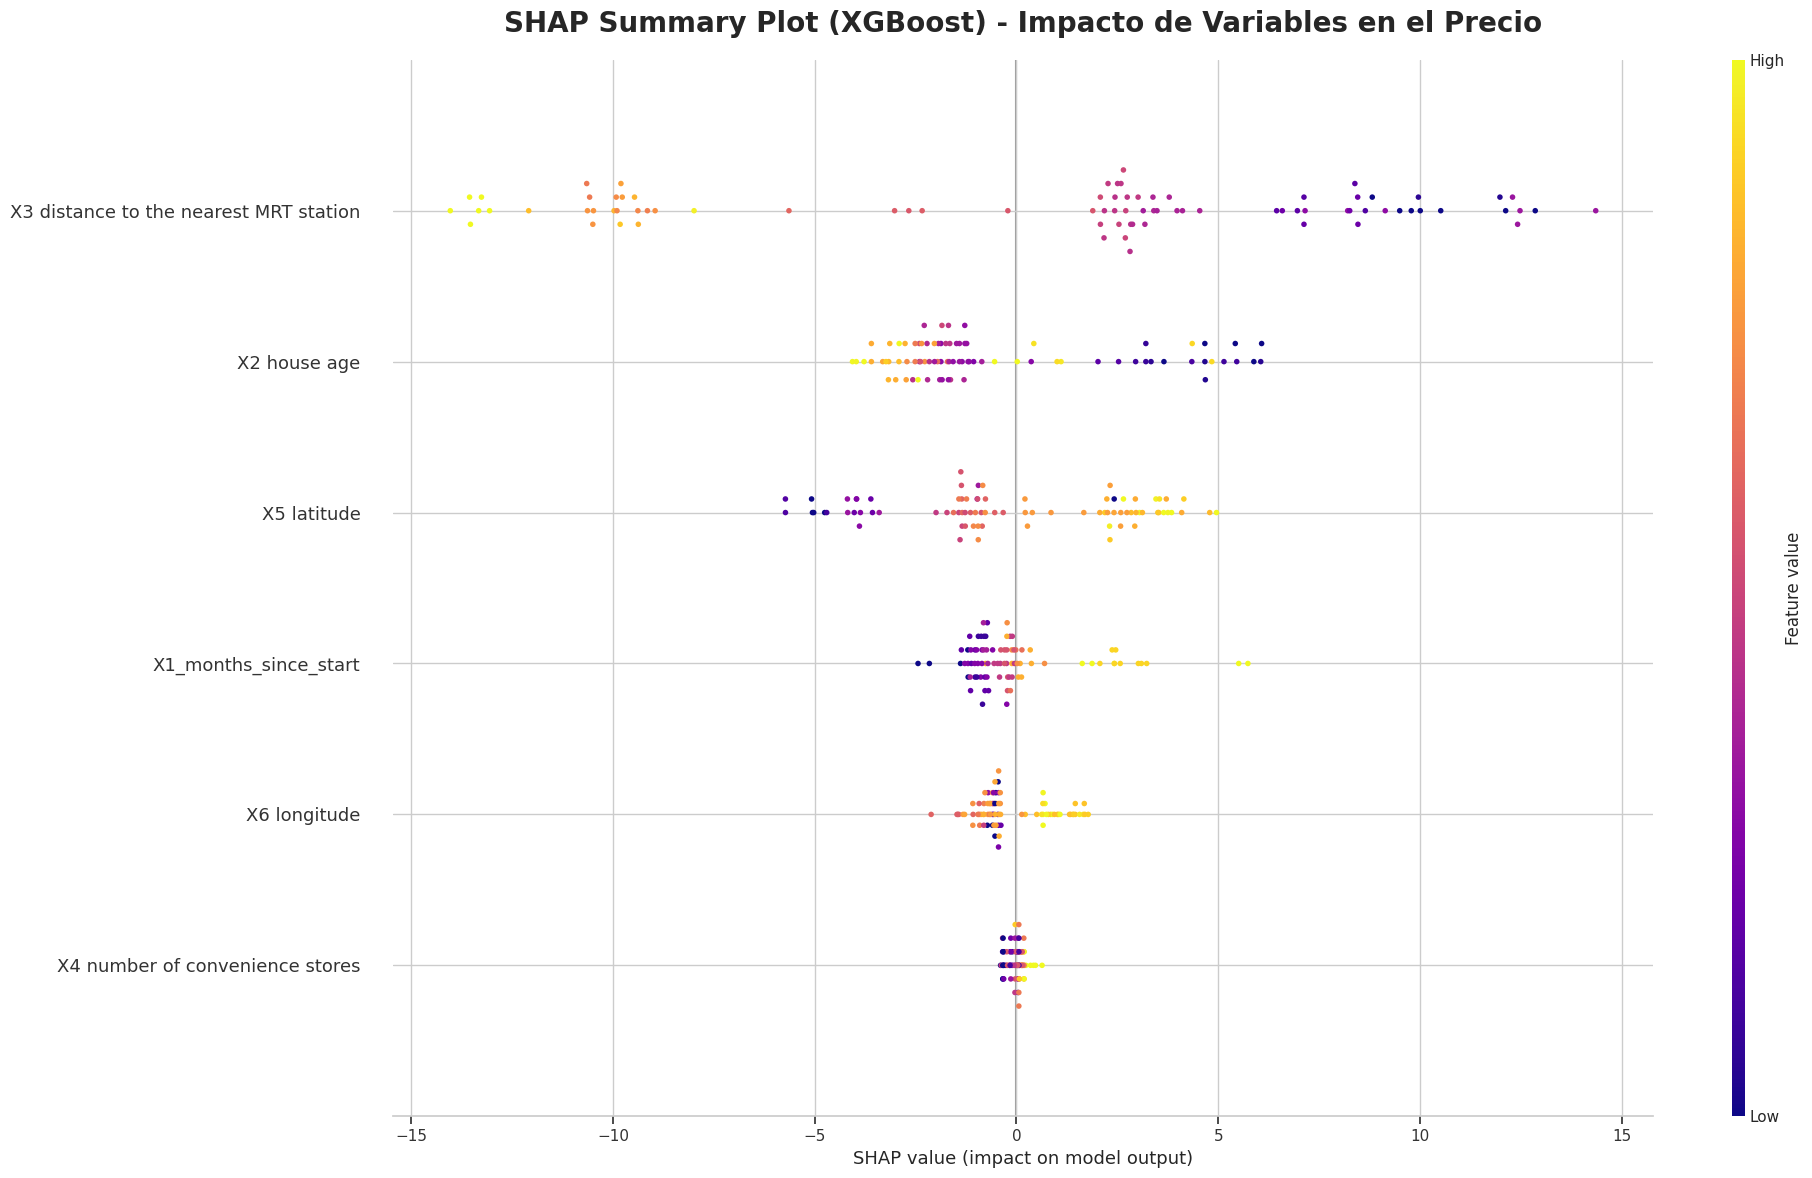


📌 Interpretación del Summary Plot:
• **Eje X (SHAP value)**: Impacto en la predicción
  - Valores positivos (derecha) → AUMENTAN el precio predicho
  - Valores negativos (izquierda) → DISMINUYEN el precio predicho

• **Eje Y**: Variables ordenadas por importancia global (de mayor a menor impacto)

• **Color (intensidad de la feature)**:
  - 🟡 Amarillo/Rojo = Valor ALTO de la variable
  -  Morado/Azul = Valor BAJO de la variable

• **Ejemplo clave (X3 - Distancia MRT)**:
  - Puntos morados (cerca del metro) están a la DERECHA → suben el precio ✅
  - Puntos amarillos (lejos del metro) están a la IZQUIERDA → bajan el precio ❌

• **X2 (Edad de la casa)**:
  - Puntos amarillos (casas viejas) tienden a la izquierda → bajan el precio
  - Puntos morados (casas nuevas) tienden a la derecha → suben el precio

✅ FASE 5 COMPLETADA. Los modelos han sido evaluados y visualizados.


In [77]:
# ==========================================================
# FASE 5: EVALUACIÓN Y COMPARACIÓN DE MODELOS
# ==========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import math

print("="*60)
print("FASE 5: EVALUACIÓN, MÉTRICAS Y VISUALIZACIÓN")
print("="*60)

# ----------------------------------------------------------
# 5.1. CÁLCULO DE MÉTRICAS Y TABLA COMPARATIVA
# ----------------------------------------------------------
print("\n 5.1. Calculando métricas para cada modelo en el conjunto de Test...")

# Función para calcular el R² Ajustado
def adjusted_r2(y_true, y_pred, n_features):
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    p = n_features
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

metrics_data = []
n_features = X_test.shape[1]

for name, y_pred in predicciones_test.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100 # En porcentaje
    r2 = r2_score(y_test, y_pred)
    adj_r2 = adjusted_r2(y_test, y_pred, n_features)

    metrics_data.append([name, mae, mse, rmse, mape, r2, adj_r2])

# Crear DataFrame para visualizar la tabla
df_metrics = pd.DataFrame(metrics_data, columns=['Modelo', 'MAE', 'MSE', 'RMSE', 'MAPE (%)', 'R²', 'R² Ajustado'])

# Formatear la tabla para que se vea mejor en el output
df_metrics_display = df_metrics.copy()
for col in ['MAE', 'MSE', 'RMSE', 'R²', 'R² Ajustado']:
    df_metrics_display[col] = df_metrics_display[col].round(4)
df_metrics_display['MAPE (%)'] = df_metrics_display['MAPE (%)'].round(2)

print("\n📊 TABLA COMPARATIVA DE MÉTRICAS (Conjunto de Test)")
display(df_metrics_display)

# ----------------------------------------------------------
# 5.2. GRÁFICO: VALORES REALES vs. PREDICHOS
# ----------------------------------------------------------
print("\n 5.2. Generando gráficos de Valores Reales vs. Predichos...")

fig_real_vs_pred = make_subplots(rows=1, cols=3, subplot_titles=list(predicciones_test.keys()))

for i, (name, y_pred) in enumerate(predicciones_test.items()):
    # Puntos dispersos (predicciones)
    fig_real_vs_pred.add_trace(
        go.Scatter(x=y_test, y=y_pred, mode='markers', marker_color=matlab_colors[i],
                   name=name, opacity=0.7, marker_size=6),
        row=1, col=i+1
    )
    # Línea diagonal perfecta (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    fig_real_vs_pred.add_trace(
        go.Scatter(x=[min_val, max_val], y=[min_val, max_val], mode='lines',
                   line=dict(color='black', dash='dash', width=2), showlegend=False),
        row=1, col=i+1
    )

fig_real_vs_pred.update_layout(
    title_text="Valores Reales vs. Valores Predichos (Línea negra = Predicción perfecta)",
    template='matlab',
    height=400
)
fig_real_vs_pred.update_xaxes(title_text="Precio Real (Y)", row=1, col=1)
fig_real_vs_pred.update_yaxes(title_text="Precio Predicho", row=1, col=1)
fig_real_vs_pred.show()

#==========================================================
# 5.3. GRÁFICO DE RESIDUOS (Errores)
#==========================================================
print("\n 5.3. Generando gráficos de Residuos (deben centrarse en 0 sin patrones)...")

fig_residuos = make_subplots(
    rows=1, cols=3,
    subplot_titles=list(predicciones_test.keys())
)

for i, (name, y_pred) in enumerate(predicciones_test.items()):
    residuos = y_test - y_pred

    # Histograma de residuos
    fig_residuos.add_trace(
        go.Histogram(
            x=residuos,
            nbinsx=20,
            marker_color=matlab_colors[i],
            name=name,
            opacity=0.75
        ),
        row=1, col=i+1
    )

    # Línea vertical en 0 (los residuos deben centrarse aquí)
    fig_residuos.add_vline(
        x=0, line=dict(color="red", dash="dash", width=2),
        row=1, col=i+1
    )

fig_residuos.update_layout(
    title_text="Distribución de Residuos por Modelo (centrados en 0 = buen ajuste)",
    showlegend=False,
    template='matlab',
    height=450
)
fig_residuos.update_xaxes(title_text="Residuo (y_real - y_pred)", row=1, col=1)
fig_residuos.update_xaxes(title_text="Residuo (y_real - y_pred)", row=1, col=2)
fig_residuos.update_xaxes(title_text="Residuo (y_real - y_pred)", row=1, col=3)
fig_residuos.update_yaxes(title_text="Frecuencia", row=1, col=1)
fig_residuos.show()

#==========================================================
# 5.4. IMPORTANCIA DE VARIABLES (Feature Importance vs Coeficientes)
#==========================================================
print("\n🔹 5.4. Comparando importancia de variables entre modelos...")

# Extraer importancias
importancias = {
    'Regresión Lineal\n(coef. abs.)': np.abs(modelos_entrenados['Regresión Lineal'].coef_),
    'Random Forest': modelos_entrenados['Random Forest'].feature_importances_,
    'XGBoost': modelos_entrenados['XGBoost'].feature_importances_
}

features = X.columns.tolist()

# Nombres cortos en español para evitar superposición con las barras
features_short = ['Edad casa', 'Dist. MRT', 'Tiendas', 'Latitud', 'Longitud', 'Meses']

# Crear figura con 3 subplots - ANCHO AMPLIADO Y ESPACIADO REDUCIDO
fig_imp = make_subplots(
    rows=1, cols=3,
    subplot_titles=list(importancias.keys()),
    horizontal_spacing=0.08  # Reducido de 0.18 a 0.08 para aprovechar mejor el ancho
)

for i, (modelo_name, valores) in enumerate(importancias.items()):
    # Ordenar de mayor a menor para mejor visualización
    orden = np.argsort(valores)[::-1]
    valores_ord = valores[orden]
    features_ord = [features_short[j] for j in orden]  # Usar nombres cortos

    fig_imp.add_trace(
        go.Bar(
            x=valores_ord,
            y=features_ord,
            orientation='h',
            marker_color=matlab_colors[i],
            name=modelo_name,
            showlegend=False,
            text=[f'{v:.3f}' for v in valores_ord],  # Añadir valores numéricos
            textposition='outside',
            textfont=dict(size=9)
        ),
        row=1, col=i+1
    )

fig_imp.update_layout(
    title_text="Importancia de Variables por Modelo (mayor valor = mayor influencia en el precio)",
    template='matlab',
    height=500,
    width=1800,  # AUMENTADO de 1400 a 1800 para que los 3 gráficos se vean completos
    margin=dict(l=120, r=50, t=80, b=50)  # Más espacio a la izquierda para etiquetas
)

# Ajustar el ancho del eje Y para que quepan los nombres
fig_imp.update_yaxes(
    tickfont=dict(size=11),
    row=1, col=1
)
fig_imp.update_yaxes(
    tickfont=dict(size=11),
    row=1, col=2
)
fig_imp.update_yaxes(
    tickfont=dict(size=11),
    row=1, col=3
)

fig_imp.show()

# Interpretación rápida
print("\n📌 Interpretación:")
print("• En modelos lineales: los coeficientes (en valor absoluto) indican la magnitud del efecto sobre Y.")
print("• En árboles (RF, XGBoost): la importancia mide cuánto reduce cada variable la impureza/varianza.")

#==========================================================
# 5.5. EXPLICABILIDAD DEL MODELO (SHAP) - NIVEL KAGGLE
#==========================================================
print("\n🔹 5.5. Generando análisis SHAP para XGBoost (Explainable AI)...")
import shap

# Configuración global de matplotlib para que el gráfico SHAP se vea bien
plt.rcParams.update({
    'figure.figsize': (20, 12),  # Figura muy grande
    'figure.dpi': 100,
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 20
})

# Creamos el explicador para el modelo ganador (XGBoost)
explainer = shap.TreeExplainer(mejor_xgb)
shap_values = explainer.shap_values(X_test_scaled)

# Crear figura explícita con tamaño grande
fig, ax = plt.subplots(figsize=(20, 12))

# Generar el SHAP summary plot con configuración personalizada
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=X.columns.tolist(),
    show=False,
    max_display=6,
    cmap='plasma',  # Paleta que coincide con MATLAB Parula
    plot_size=None,  # Dejar que matplotlib controle el tamaño
    color_bar=True
)

# Ajustar el título
ax.set_title("SHAP Summary Plot (XGBoost) - Impacto de Variables en el Precio",
             fontsize=20, fontweight='bold', pad=20)

# Ajustar márgenes para eliminar espacio vacío
plt.subplots_adjust(left=0.25, right=0.85, top=0.90, bottom=0.15)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Restaurar configuración original de matplotlib
plt.rcParams.update({
    'figure.figsize': (6.4, 4.8),
    'font.size': 10
})

print("\n📌 Interpretación del Summary Plot:")
print("• **Eje X (SHAP value)**: Impacto en la predicción")
print("  - Valores positivos (derecha) → AUMENTAN el precio predicho")
print("  - Valores negativos (izquierda) → DISMINUYEN el precio predicho")
print("\n• **Eje Y**: Variables ordenadas por importancia global (de mayor a menor impacto)")
print("\n• **Color (intensidad de la feature)**:")
print("  - 🟡 Amarillo/Rojo = Valor ALTO de la variable")
print("  -  Morado/Azul = Valor BAJO de la variable")
print("\n• **Ejemplo clave (X3 - Distancia MRT)**:")
print("  - Puntos morados (cerca del metro) están a la DERECHA → suben el precio ✅")
print("  - Puntos amarillos (lejos del metro) están a la IZQUIERDA → bajan el precio ❌")
print("\n• **X2 (Edad de la casa)**:")
print("  - Puntos amarillos (casas viejas) tienden a la izquierda → bajan el precio")
print("  - Puntos morados (casas nuevas) tienden a la derecha → suben el precio")

print("\n✅ FASE 5 COMPLETADA. Los modelos han sido evaluados y visualizados.")

# Fase 6: Conclusiones y Análisis Crítico

## 1. ¿Cuál modelo tuvo mejor desempeño?

Según la tabla comparativa de métricas, el modelo con mejor desempeño general es **XGBoost**, ya que presenta:

- **RMSE más bajo (7.1141)** → menor error cuadrático medio en las mismas unidades del precio
- **R² más alto (0.6729)** → explica el 67.29% de la varianza en los precios de vivienda
- **R² Ajustado más alto (0.6471)** → considerando la penalización por número de predictores
- **MAPE competitivo (18.11%)** → error relativo aceptable para predicciones inmobiliarias

Sin embargo, es importante destacar que **Random Forest obtuvo el mejor MAE (4.8732)**, lo que indica que en promedio sus predicciones tienen menor error absoluto.

---

## 2. ¿Coinciden todas las métricas?

**No coinciden completamente**, y esto revela información valiosa sobre el comportamiento de los modelos:

- **XGBoost** domina en métricas que penalizan errores grandes (RMSE, R², R² Ajustado)
- **Random Forest** lidera en MAE, que mide el error promedio sin penalizar outliers

### ¿Por qué ocurre esta discrepancia?

El **RMSE** eleva los errores al cuadrado, por lo que penaliza fuertemente las predicciones con errores grandes. **XGBoost**, al ser un modelo de boosting que corrige errores iterativamente, es más efectivo minimizando estos errores extremos. **Random Forest**, al promediar múltiples árboles, tiende a tener predicciones más conservadoras con menor error promedio pero posiblemente más errores moderados.

### ¿Cuál elegir en un escenario real?

Para una tasadora inmobiliaria, **XGBoost sería la mejor opción** porque:

- Un error grande en una tasación puede tener consecuencias financieras significativas
- El menor RMSE indica mejor control de errores extremos
- El mayor R² sugiere mejor capacidad explicativa del modelo

---

## 3. Variables con mayor influencia en el precio

De acuerdo con el análisis de importancia de variables (Feature Importance) y el análisis SHAP, el ranking de importancia es:

### 1. Distancia a la estación MRT (X3) - Importancia: 65.4%
- Correlación negativa fuerte (-0.67)
- A mayor distancia al metro, menor precio de la vivienda
- Es el factor determinante más importante del mercado inmobiliario en este dataset
- Las casas cercanas al transporte público tienen prima de valor significativa

### 2. Latitud (X5) - Importancia: 10.5%
- Captura la ubicación geográfica norte-sur
- Refleja diferencias en valor entre diferentes zonas de la ciudad
- Probablemente correlacionada con distritos más o menos desarrollados

### 🟡 3. Edad de la casa (X2) - Importancia: 10.0%
- Correlación negativa (-0.21)
- Casas más nuevas tienden a tener mayor valor
- El efecto es moderado comparado con la ubicación

### 🟢 4. Longitud (X6) - Importancia: 6.2%
- Complementa la latitud para definir ubicación exacta
- Captura variaciones este-oeste en el valor de propiedades

### 5. Meses transcurridos (X1) - Importancia: 4.5%
- Refleja la tendencia temporal del mercado
- Efecto moderado, sugiere estabilidad relativa del mercado en el periodo analizado

### 6. Número de tiendas de conveniencia (X4) - Importancia: 3.4%
- Correlación positiva (0.57)
- Más servicios cercanos incrementan el valor
- Efecto positivo pero de menor magnitud

---

## 4. Análisis del Modelo Ganador (XGBoost)

### Fortalezas identificadas:

- **Capacidad de capturar no linealidades**: A diferencia de la regresión lineal, XGBoost modela relaciones complejas entre variables
- **Robustez ante outliers**: El algoritmo de boosting corrige errores iterativamente
- **Interpretabilidad**: A través de SHAP values podemos entender cómo cada variable afecta las predicciones
- **Eficiencia computacional**: Entrenamiento en 8.64 segundos vs 60.84 segundos de Random Forest

### Interpretación de SHAP Values:

- **Distancia MRT**: Valores bajos (cerca del metro) aumentan el precio predicho, valores altos (lejos) lo disminuyen
- **Edad de la casa**: Casas nuevas (valores bajos) tienden a aumentar el precio, casas viejas lo disminuyen
- **Tiendas de conveniencia**: Más tiendas cercanas incrementan el valor de la propiedad

---

## 5. Limitaciones del Análisis

### Limitaciones de datos:

- **Tamaño de muestra reducido**: Solo 414 registros limitan la capacidad de generalización y el tuning profundo de hiperparámetros
- **Falta de variables contextuales importantes**:
  - Datos socioeconómicos del barrio (ingresos promedio, nivel educativo)
  - Tasas de criminalidad
  - Calidad de escuelas cercanas
  - Acceso a servicios públicos (hospitales, parques)
  - Antigüedad de infraestructura urbana
- **Periodo temporal limitado**: Los datos abarcan solo ~2 años, insuficiente para capturar ciclos inmobiliarios completos
- **Ausencia de características de la propiedad**:
  - Metros cuadrados totales
  - Número de habitaciones/baños
  - Estado de conservación
  - Amenidades (estacionamiento, seguridad, etc.)

### Limitaciones metodológicas:

- **División train/test simple**: No se utilizó validación cruzada anidada para estimar mejor el error de generalización
- **Ausencia de test estadísticos**: No se realizaron pruebas de normalidad de residuos ni tests de homocedasticidad
- **Features engineering limitado**: No se exploraron interacciones entre variables ni transformaciones polinómicas
- **Tratamiento de outliers**: La eliminación del outlier (precio=117.5) fue arbitraria; se pudo haber usado técnicas más robustas como Winsorization

---

## 6. Mejoras Futuras Recomendadas

### A. Mejoras en el preprocesamiento:

- **Validación cruzada anidada (Nested CV)**: Implementar GridSearchCV con validación cruzada anidada para estimar mejor el error real del modelo
- **Tratamiento robusto de outliers**: Usar técnicas como IQR method, Z-score, o algoritmos como Isolation Forest
- **Feature engineering avanzado**:
  - Crear variables de interacción (distancia × tiendas, edad × ubicación)
  - Features polinómicas para capturar relaciones no lineales
  - Clustering geográfico (K-Means sobre latitud/longitud) para crear zonas de valor
- **Selección de features**: Implementar RFE (Recursive Feature Elimination), Lasso, o SelectKBest

### B. Mejoras en el modelado:

- **Modelos adicionales a probar**:
  - Support Vector Regression (SVR) con diferentes kernels
  - Redes neuronales profundas (MLP Regressor)
  - Modelos de ensemble avanzados (Stacking, Blending)
  - LightGBM (alternativa más rápida a XGBoost)
  - CatBoost (excelente para datos con características categóricas)
- **Optimización de hiperparámetros**:
  - Usar Optuna o Hyperopt en lugar de GridSearchCV para búsqueda más eficiente
  - Expandir el espacio de búsqueda de hiperparámetros
  - Implementar early stopping para prevenir overfitting
- **Ensemble methods**: Combinar predicciones de múltiples modelos (voting, stacking, blending)

### C. Mejoras en la evaluación:

- **Métricas adicionales**:
  - Mediana del error absoluto (más robusta que MAE)
  - Intervalos de confianza para las predicciones
  - Análisis de errores por segmento (zonas geográficas, rangos de precio)
- **Tests estadísticos**:
  - Prueba de Shapiro-Wilk para normalidad de residuos
  - Test de Breusch-Pagan para homocedasticidad
  - Test de Durbin-Watson para autocorrelación
- **Análisis de residuos más profundo**:
  - Gráficos de residuos vs valores predichos
  - Gráficos Q-Q para verificar normalidad
  - Análisis de leverage e influencia

### D. Mejoras en la interpretabilidad:

- **Análisis SHAP más detallado**:
  - SHAP dependence plots para cada variable
  - SHAP interaction values para entender interacciones
  - Force plots para explicaciones individuales
- **Partial Dependence Plots (PDP)**: Visualizar el efecto marginal de cada variable
- **LIME (Local Interpretable Model-agnostic Explanations)**: Explicaciones locales para predicciones individuales

### E. Mejoras en los datos:

- **Recolección de datos adicionales**:
  - Variables socioeconómicas del barrio
  - Datos de transporte público (frecuencia, cobertura)
  - Información sobre desarrollo urbano futuro
  - Datos históricos de precios para análisis de tendencias
- **Aumento de muestra**: Recopilar más datos de diferentes periodos y zonas
- **Datos externos**: Integrar información de APIs gubernamentales, mapas, etc.

# 7. Conclusiones Finales

## Logros del proyecto:

✅ Se implementó un pipeline completo de Machine Learning para regresión  
✅ Se compararon 3 algoritmos diferentes con métricas estandarizadas  
✅ Se realizó análisis exploratorio de datos exhaustivo  
✅ Se aplicaron técnicas de preprocesamiento apropiadas  
✅ Se logró un modelo con R² de 0.67, explicando el 67% de la varianza  
✅ Se interpretaron los resultados usando SHAP values  

---

## Hallazgos clave:

- **La ubicación es el factor más importante**: La distancia al metro explica la mayor parte de la variación en precios
- **XGBoost supera a modelos más simples**: El boosting iterativo es efectivo para este tipo de datos
- **Las métricas pueden dar resultados diferentes**: Es crucial analizar múltiples métricas para entender el comportamiento del modelo
- **El dataset tiene limitaciones**: 414 registros es insuficiente para modelos complejos

---

## Recomendación final:

Para un sistema de tasación inmobiliaria en producción, se recomienda:

1. **Usar XGBoost como modelo base**
2. **Recolectar más datos con variables adicionales**
3. **Implementar validación cruzada anidada para estimación robusta del error**
4. **Agregar intervalos de confianza a las predicciones**
5. **Desarrollar un sistema de monitoreo para detectar drift en los datos**

> El modelo actual es un buen punto de partida, pero requiere mejoras significativas en datos y validación antes de ser desplegado en un entorno de producción real.